---
# Tutoriumsblatt 6: Visualisierung der Aufgaben
SS 2025 – Tutorium: Markovsche Ketten <br>
[Ilias Seite zum Kurs](https://ilias.studium.kit.edu/goto.php?target=crs_2640974&client_id=produktiv) <br>
Dominik Ebert

---

---
## T2 (Zyklische Irrfahrt) + Totalvariationsabstand
---

## 1. Übgergangswahrscheinlichkeit

In [36]:
import numpy as np

In [37]:
# Implementierung der Übergangsmatrix P
states = np.array([0, 1, 2, 3, 4])
N = len(states)

# P ist eine Numpy-Matrix mit N Zeilen und N Spalten
P = np.zeros((N, N))

# Die Übergangswahrscheinlichkeiten werden in die Matrix P eingetragen
# z.B P[0, 0] = 0.5 
# Die Wahrscheinlichkeit, von einem Zustand i nach (i + 1) mod 5 oder (i − 1) mod 5 zu gelangen, 
# ist hier jeweils 0.5
P[0, 1] = 0.5; P[0, 4] = 0.5
P[1, 0] = 0.5; P[1, 2] = 0.5
P[2, 1] = 0.5; P[2, 3] = 0.5
P[3, 2] = 0.5; P[3, 4] = 0.5
P[4, 3] = 0.5; P[4, 0] = 0.5
# Die Matrix P ist jetzt vollständig definiert
print(P)

[[0.  0.5 0.  0.  0.5]
 [0.5 0.  0.5 0.  0. ]
 [0.  0.5 0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5]
 [0.5 0.  0.  0.5 0. ]]


Wir verwenden die Beziehung

$$
P(X_{n+m} = j | X_m = i) = p^{(n)}_{ij} \quad \text{für alle } i, j \in S, \, m, n \in \mathbb{N}_0, \text{ mit } P(X_m = i) > 0.
$$

Dazu berechnen wir $ P^3 $ ,  um die 3-Schritt-Übergangswahrscheinlichkeiten zu bestimmen. Wir erhalten:

In [38]:
# Die Matrix P^3 wird berechnet
np.linalg.matrix_power(P, 3)

array([[0.   , 0.375, 0.125, 0.125, 0.375],
       [0.375, 0.   , 0.375, 0.125, 0.125],
       [0.125, 0.375, 0.   , 0.375, 0.125],
       [0.125, 0.125, 0.375, 0.   , 0.375],
       [0.375, 0.125, 0.125, 0.375, 0.   ]])

In [39]:
# mit festem Startzustand 1
v = np.array([0, 1, 0, 0, 0]) # Startvektor

# Die Matrix P^3 wird auf den Startzustand x angewendet
x3 = np.dot(v, np.linalg.matrix_power(P, 3))
print(x3)

[0.375 0.    0.375 0.125 0.125]


Kommentar: Dies entspricht gerade der 2. Zeile ($\hat{=} 1$, da Index bei 0 beginnend) der Matrix $P^3$

Im Folgenden visualisieren wir uns die n-Schritt-Übergangswahrscheinlichkeiten vom Startzustand 1.

In [40]:
import matplotlib.pyplot as plt

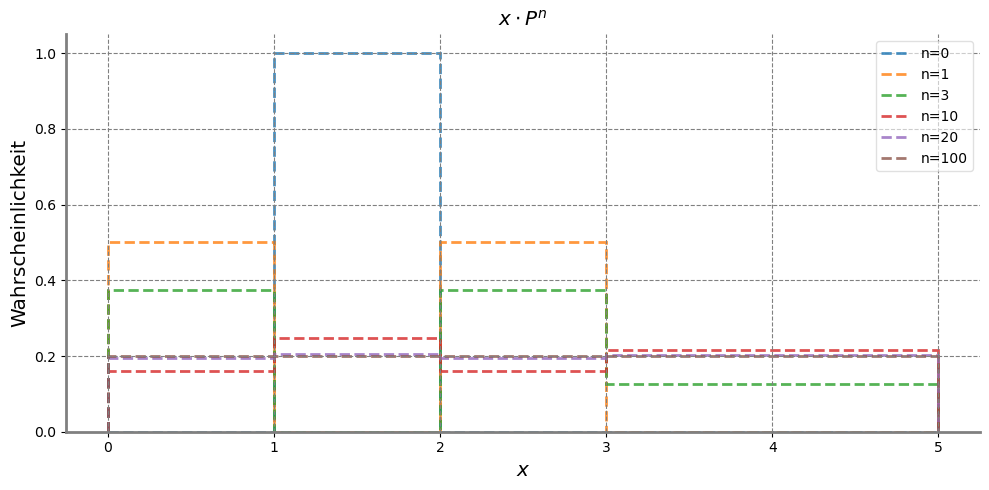

In [41]:
# Werte für n
n_values = [0, 1, 3, 10, 20, 100]

# Bereich für die x-Achse
x_range = np.linspace(0, 5, 100)

# Plot erstellen
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True, linestyle='--', color='grey')
ax.set_axisbelow = False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Plotten von P^n * x für verschiedene n
for n in n_values:
    result = np.dot(v, np.linalg.matrix_power(P, n))
    ax.stairs(result, label=f"n={n}", alpha=0.8, fill=False, linewidth=2, linestyle='--')

# Legende und Achsentitel
legend = ax.legend(fontsize="medium", markerscale=1, framealpha=0.6, loc="upper right")
ax.set_xlabel('$x$', fontsize='x-large')
ax.set_ylabel('Wahrscheinlichkeit', fontsize='x-large')
ax.set_title('$x \cdot P^n$', fontsize='x-large')
plt.tight_layout()
plt.show()

## 1. Totalvariatonsabstand

In [42]:
# implement the metric and test it for a simple example

a = np.array([0.5, 0.5, 0, 0, 0])
b = np.array([0, 0.5, 0.5, 0, 0])

In [43]:
def d(a, b):
    return (1/2)*abs(a - b).sum()

d(a,b)
    

0.5

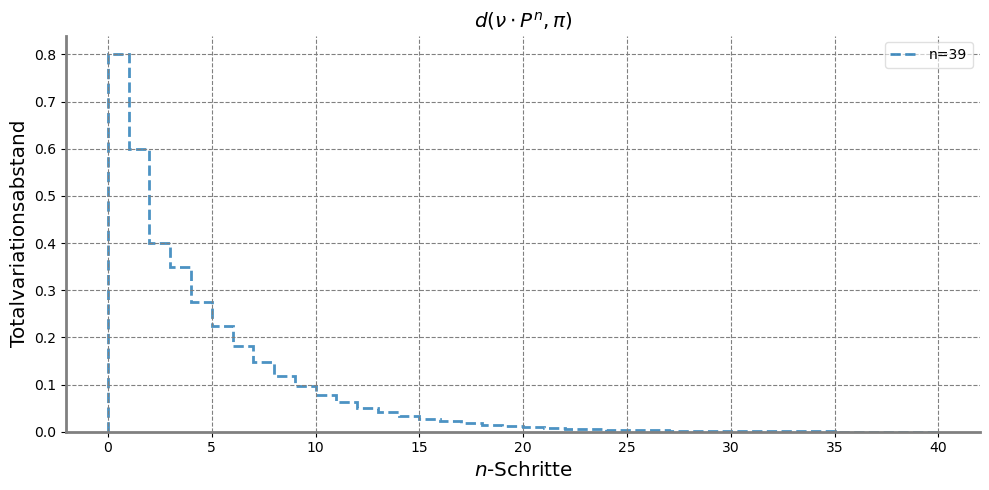

In [44]:
# Werte für n
n_values = [0, 1, 3, 10, 20, 100]

# Bereich für die x-Achse
x_range = np.linspace(0, 1, 100)

# definition of the stationary distribution !!!
stat_v = np.ones(5)/5

# mit festem Startzustand 1
v = np.array([0, 1, 0, 0, 0]) # Startvektor

# Plot erstellen
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()
ax.grid(True, linestyle='--', color='grey')
ax.set_axisbelow = False
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

result = []
# Plotten von P^n * x für verschiedene n
for n in range(40):
    result.append(d(np.dot(v, np.linalg.matrix_power(P, n)), stat_v))

ax.stairs(result, label=f"n={n}", alpha=0.8, fill=False, linewidth=2, linestyle='--')

# Legende und Achsentitel
legend = ax.legend(fontsize="medium", markerscale=1, framealpha=0.6, loc="upper right")
ax.set_xlabel('$n$-Schritte', fontsize='x-large')
ax.set_ylabel('Totalvariationsabstand', fontsize='x-large')
ax.set_title('$d(\\nu \cdot P^n, \pi)$', fontsize='x-large')
plt.tight_layout()
plt.show()